In [1]:
!sudo apt-get update
!sudo apt-get install --yes build-essential curl automake
!curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash
!pip install mecab-python3

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.10ubuntu1).
curl is already the newest version (8.5.0-2ubuntu10.9).
automake is already the newest version (1:1.16.5-1.3ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 135 not upgraded.
mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [2]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [3]:
import os

import matplotlib.pyplot as plt
import torch
import numpy as np

%matplotlib inline

In [4]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-06-19 16:50:00--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-06-19 16:50:01--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz’

korean-e

In [5]:
import os
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


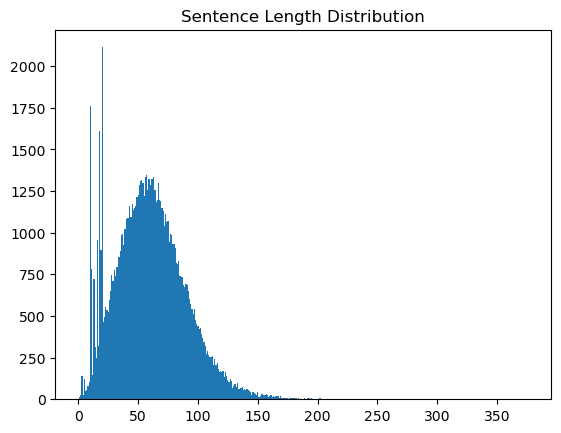

In [6]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [7]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


In [8]:
for idx, _sum in enumerate(sentence_length):
    # 문장의 수가 1500을 초과하는 문장 길이를 추출합니다.
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


In [9]:
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


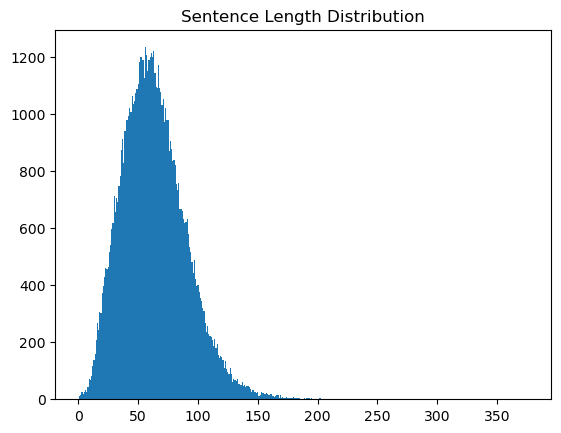

In [10]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

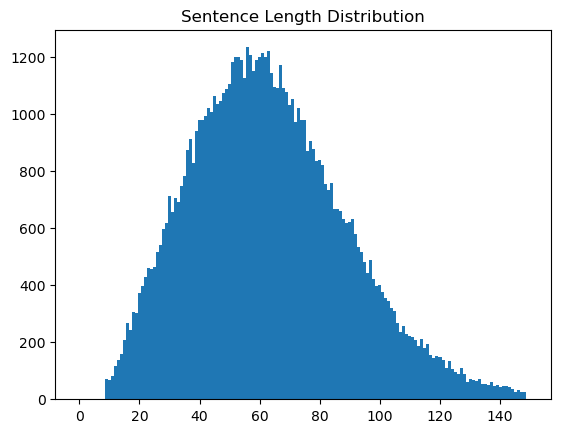

In [11]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [15]:
import sentencepiece as spm
import os
temp_file = 'korean-english-park.train.ko.temp'

vocab_size = 8000

with open(temp_file, 'w') as f:
    for row in filtered_corpus:   # 이전에 나왔던 정제했던 corpus를 활용해서 진행해야 합니다.
        f.write(str(row) + '\n')

spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)    
)
#위 Train에서  --model_type = unigram이 디폴트 적용되어 있습니다. --model_type = bpe로 옵션을 주어 변경할 수 있습니다.

!ls -l korean_spm*

-rw-r--r-- 1 jovyan users 379826 Jun 19 17:04 korean_spm.model
-rw-r--r-- 1 jovyan users 146754 Jun 19 17:04 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean-english-park.train.ko.temp --model_prefix=korean_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean-english-park.train.ko.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  b

In [16]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1246, 11, 302, 7, 3541, 11, 287, 33, 4]
['▁아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


In [21]:
import torch

def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(sen), dtype=torch.long))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

In [22]:
from torch.nn.utils.rnn import pad_sequence
tensor, word_index, index_word = sp_tokenize(s, filtered_corpus[:5])
print(tensor)
print(tensor.shape)

tensor([[1602,  420,  631,   10, 1241,   18, 1678, 1662, 1602,  420,  631, 1825,
          881,   69,  484,  402,   19,  585,   15, 3261,   37,   51,   56,  274,
         2181,  633, 1955, 1413, 4282,  291,  107,    3,  864,  393, 1484,    7,
            3, 1802,   44, 7377,    8, 1249,   39,   95, 2007,  261,   20,   14,
           35,    4,    0,    0,    0,    0,    0,    0,    0],
        [2719,   28,   31,  151, 3772, 1821,  187, 1437, 1182,    6,  339,  174,
          318, 7883,  125,  454,    3,  389, 2116,   26, 6692,   10,   31,  151,
         3772,  533, 7883,  125,  194, 2592, 1182,   11, 6692,   14,   29,    4,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0],
        [ 319,  308,   12,  235,  316,    6,  331,    5, 1549, 1378, 4482,    6,
          674, 1652, 7208,    7,  195,  144,  126,   29,    4,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,

In [23]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
!head -5 ratings_train.txt

--2026-06-19 17:34:47--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  44.5MB/s    in 0.3s    

2026-06-19 17:34:48 (44.5 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-06-19 17:34:49--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet

In [24]:
import pandas as pd

train_data = pd.read_csv('ratings_train.txt', sep='\t')
test_data = pd.read_csv('ratings_test.txt', sep='\t')

print("훈련 데이터 크기:", len(train_data))
print("테스트 데이터 크기:", len(test_data))
train_data.head()

훈련 데이터 크기: 150000
테스트 데이터 크기: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [25]:
# 결측치 확인
print(train_data.isnull().sum())

# 결측치 제거
train_data = train_data.dropna(how='any')
print("결측치 제거 후:", len(train_data))

# document 컬럼 중복 제거
train_data = train_data.drop_duplicates(subset=['document'])
print("중복 제거 후:", len(train_data))

id          0
document    5
label       0
dtype: int64
결측치 제거 후: 149995
중복 제거 후: 146182


최단 길이: 1
최장 길이: 146
평균 길이: 35.981338331668745


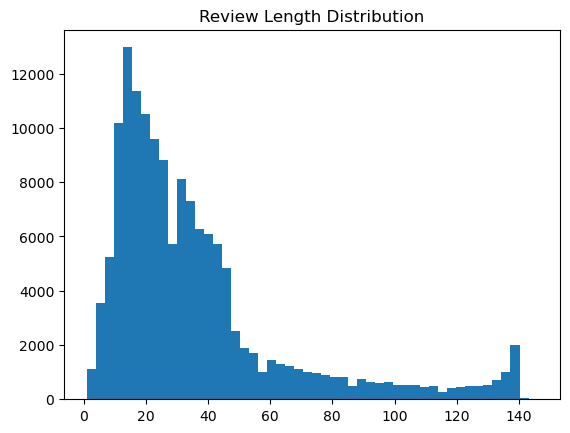

In [26]:
import numpy as np

lengths = train_data['document'].apply(len)
print("최단 길이:", lengths.min())
print("최장 길이:", lengths.max())
print("평균 길이:", lengths.mean())

plt.hist(lengths, bins=50)
plt.title("Review Length Distribution")
plt.show()

In [27]:
# 너무 짧은(한 글자짜리 등 의미 파악이 어려운) 리뷰는 SentencePiece 학습에 노이즈가 되므로 제외
min_len = 2
max_len = 146  # 데이터 내 최대 길이 그대로 사용 (더 자를 필요 없음)

# 길이 조건에 맞는 리뷰만 선택해서 SentencePiece 학습용 코퍼스 생성
naver_corpus = [s for s in train_data['document'] if (len(s) >= min_len) and (len(s) <= max_len)]

print("필터링 전 데이터 크기:", len(train_data))
print("필터링 후 코퍼스 크기:", len(naver_corpus))
print("예시 문장:", naver_corpus[:5])

필터링 전 데이터 크기: 146182
필터링 후 코퍼스 크기: 146081
예시 문장: ['아 더빙.. 진짜 짜증나네요 목소리', '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', '너무재밓었다그래서보는것을추천한다', '교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정', '사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']


In [28]:
# naver_corpus를 텍스트 파일로 저장 (SentencePiece는 파일 경로를 입력으로 받기 때문)
naver_temp_file = 'naver_review.train.temp'
naver_vocab_size = 8000

with open(naver_temp_file, 'w') as f:
    for row in naver_corpus:
        f.write(str(row) + '\n')

# SentencePiece 모델 학습 (model_prefix를 naver_spm으로 지정해 기존 korean_spm과 구분)
spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=naver_spm --vocab_size={}'.format(naver_temp_file, naver_vocab_size)
)

# 생성된 모델/vocab 파일 확인
!ls -l naver_spm*

-rw-r--r-- 1 jovyan users 377482 Jun 19 17:40 naver_spm.model
-rw-r--r-- 1 jovyan users 144440 Jun 19 17:40 naver_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=naver_review.train.temp --model_prefix=naver_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: naver_review.train.temp
  input_format: 
  model_prefix: naver_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
 

In [29]:
naver_s = spm.SentencePieceProcessor()
naver_s.Load('naver_spm.model')

sample = '아 더빙.. 진짜 짜증나네요 목소리'
print(naver_s.EncodeAsIds(sample))
print(naver_s.EncodeAsPieces(sample))
print(naver_s.DecodeIds(naver_s.EncodeAsIds(sample)))

[66, 881, 6, 32, 2196, 64, 1428]
['▁아', '▁더빙', '..', '▁진짜', '▁짜증나', '네요', '▁목소리']
아 더빙.. 진짜 짜증나네요 목소리


In [30]:
# sp_tokenize 함수를 다시 정의 (vocab 파일 경로를 매개변수로 받도록 수정)
def sp_tokenize(s, corpus, vocab_file):

    tensor = []

    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(sen), dtype=torch.long))

    with open(vocab_file, 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]
        word_index.update({word: idx})
        index_word.update({idx: word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

In [32]:
# test
tensor, word_index, index_word = sp_tokenize(naver_s, naver_corpus[:5], 'naver_spm.vocab')
print(tensor)
print(tensor.shape)
print("vocab 크기:", len(word_index))

tensor([[  66,  881,    6,   32, 2196,   64, 1428,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [1804,    8, 4951,  158, 1415,   31,  250,   62,  170,  407,  370, 1331,
         6809,  829,  409,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [  24,  389, 7778,  368, 3921,  104, 6018, 2079,  300,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [1863,   11,  197,  235, 6620,    3,    6, 4368, 1300,  122,    6,  690,
          296,   98,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [2415, 2409, 2068,  166,   10,    3, 1443,  318, 2398,  508, 2686, 1805,
            7,   25, 5700,   46, 6319, 2474, 1241, 2944, 2435, 6294,    3,  114,
      

In [33]:
# train 데이터: document(텍스트)와 label(정답) 둘 다 필요
train_text = list(train_data['document'])
train_label = list(train_data['label'])

train_tensor, word_index, index_word = sp_tokenize(naver_s, train_text, 'naver_spm.vocab')

print("train_tensor shape:", train_tensor.shape)
print("라벨 개수:", len(train_label))

train_tensor shape: torch.Size([146182, 134])
라벨 개수: 146182


In [34]:
# test 데이터도 결측치 제거 후 동일하게 토큰화
test_data = test_data.dropna(how='any')

test_text = list(test_data['document'])
test_label = list(test_data['label'])

test_tensor, _, _ = sp_tokenize(naver_s, test_text, 'naver_spm.vocab')

print("test_tensor shape:", test_tensor.shape)
print("test 라벨 개수:", len(test_label))

test_tensor shape: torch.Size([49997, 118])
test 라벨 개수: 49997


In [35]:
import torch.nn as nn

class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1):
        super().__init__()
        # 토큰 ID를 dense vector로 변환 (padding_idx=0이라 패딩 토큰은 학습에서 무시됨)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # 문장의 순차적 정보를 인코딩하는 LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # LSTM의 최종 hidden state를 받아 이진 분류(긍정/부정) 출력
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)              # (batch, seq_len, embedding_dim)
        _, (hidden, _) = self.lstm(embedded)        # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)                  # (batch, hidden_dim)
        out = self.fc(hidden)                       # (batch, 1)
        return out.squeeze(1)                        # (batch,)
        

In [36]:
vocab_size = len(word_index)   # 8000
embedding_dim = 128
hidden_dim = 64

model = SentimentClassifier(vocab_size, embedding_dim, hidden_dim)
print(model)

SentimentClassifier(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [38]:
from torch.utils.data import Dataset, DataLoader

# 토큰화된 텐서와 라벨을 묶어서 PyTorch가 다룰 수 있는 Dataset 형태로 만듦
class ReviewDataset(Dataset):
    def __init__(self, tensor, labels):
        self.tensor = tensor
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tensor[idx], self.labels[idx]

# train/test Dataset 생성
train_dataset = ReviewDataset(train_tensor, train_label)
test_dataset = ReviewDataset(test_tensor, test_label)

# 배치 단위로 데이터를 꺼내주는 DataLoader 생성 (학습 시 매 epoch마다 섞기 위해 shuffle=True)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train batch 개수:", len(train_loader))
print("test batch 개수:", len(test_loader))

train batch 개수: 2285
test batch 개수: 782


In [40]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()  # 학습 모드 (dropout 등이 있다면 활성화)
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)  # 배치 데이터를 GPU로 이동

        optimizer.zero_grad()           # 이전 배치의 gradient 초기화
        output = model(x)               # 순전파: 모델 예측값(logit) 계산
        loss = criterion(output, y)     # 예측값과 실제 라벨 간 손실 계산

        loss.backward()                 # 역전파: gradient 계산
        optimizer.step()                # gradient를 이용해 가중치 업데이트

        total_loss += loss.item() * x.size(0)

        # 정확도 계산: logit이 0보다 크면 긍정(1), 작으면 부정(0)으로 판단
        preds = (torch.sigmoid(output) > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()  # 평가 모드 (gradient 계산 안 함)
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # 평가 시에는 gradient를 계산할 필요 없음 (메모리/속도 절약)
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * x.size(0)
            preds = (torch.sigmoid(output) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

In [41]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/5 | Train Loss: 0.6932, Train Acc: 0.4989 | Test Loss: 0.6933, Test Acc: 0.4965
Epoch 2/5 | Train Loss: 0.6932, Train Acc: 0.4984 | Test Loss: 0.6932, Test Acc: 0.4965
Epoch 3/5 | Train Loss: 0.6932, Train Acc: 0.5002 | Test Loss: 0.6932, Test Acc: 0.4966
Epoch 4/5 | Train Loss: 0.6932, Train Acc: 0.5015 | Test Loss: 0.6931, Test Acc: 0.5035
Epoch 5/5 | Train Loss: 0.6932, Train Acc: 0.5003 | Test Loss: 0.6932, Test Acc: 0.4965


In [43]:
from torch.nn.utils.rnn import pack_padded_sequence

class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # 패딩이 아닌 실제 토큰 길이 계산 (0이 아닌 토큰 개수)
        lengths = (x != 0).sum(dim=1).cpu()

        embedded = self.embedding(x)

        # 패딩 부분을 건너뛰도록 압축 (길이 0인 시퀀스 방지를 위해 clamp)
        lengths = lengths.clamp(min=1)
        packed = pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)

        _, (hidden, _) = self.lstm(packed)
        hidden = hidden.squeeze(0)
        out = self.fc(hidden)
        return out.squeeze(1)

In [44]:
model = SentimentClassifier(vocab_size, embedding_dim, hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [45]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/5 | Train Loss: 0.4397, Train Acc: 0.7912 | Test Loss: 0.3699, Test Acc: 0.8363
Epoch 2/5 | Train Loss: 0.3161, Train Acc: 0.8652 | Test Loss: 0.3496, Test Acc: 0.8494
Epoch 3/5 | Train Loss: 0.2737, Train Acc: 0.8859 | Test Loss: 0.3530, Test Acc: 0.8511
Epoch 4/5 | Train Loss: 0.2357, Train Acc: 0.9035 | Test Loss: 0.3580, Test Acc: 0.8529
Epoch 5/5 | Train Loss: 0.1993, Train Acc: 0.9214 | Test Loss: 0.3876, Test Acc: 0.8508


In [46]:
from konlpy.tag import Mecab
mecab = Mecab()

# 전체 train/test 리뷰를 형태소 단위로 분리
train_text = list(train_data['document'])
test_text = list(test_data['document'])

train_tokens = [mecab.morphs(sen) for sen in train_text]
test_tokens = [mecab.morphs(sen) for sen in test_text]

print(train_tokens[0])
print(test_tokens[0])

['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']
['굳', 'ㅋ']


In [47]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        # corpus(토큰 리스트들의 리스트)를 보고 단어사전을 구축
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1  # 0은 padding용으로 비워둠
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]  # 사전에 없는 단어는 0(OOV)
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences


# train 데이터(형태소 토큰 리스트)로 단어사전 구축
mecab_tokenizer = Tokenizer()
mecab_tokenizer.fit_on_texts(train_tokens)

mecab_vocab_size = len(mecab_tokenizer.word_index) + 1  # 0(padding)까지 포함
print("Mecab 기반 vocab 크기:", mecab_vocab_size)

Mecab 기반 vocab 크기: 54045


In [48]:
train_seqs = mecab_tokenizer.texts_to_sequences(train_tokens)
test_seqs = mecab_tokenizer.texts_to_sequences(test_tokens)

# 길이가 제각각인 시퀀스들을 패딩해서 하나의 텐서로 만듦
mecab_train_tensor = pad_sequence(train_seqs, batch_first=True, padding_value=0)
mecab_test_tensor = pad_sequence(test_seqs, batch_first=True, padding_value=0)

print("mecab_train_tensor shape:", mecab_train_tensor.shape)
print("mecab_test_tensor shape:", mecab_test_tensor.shape)

mecab_train_tensor shape: torch.Size([146182, 116])
mecab_test_tensor shape: torch.Size([49997, 105])


In [49]:
mecab_train_dataset = ReviewDataset(mecab_train_tensor, train_label)
mecab_test_dataset = ReviewDataset(mecab_test_tensor, test_label)

mecab_train_loader = DataLoader(mecab_train_dataset, batch_size=batch_size, shuffle=True)
mecab_test_loader = DataLoader(mecab_test_dataset, batch_size=batch_size, shuffle=False)

print("train batch 개수:", len(mecab_train_loader))
print("test batch 개수:", len(mecab_test_loader))

train batch 개수: 2285
test batch 개수: 782


In [50]:
mecab_model = SentimentClassifier(mecab_vocab_size, embedding_dim, hidden_dim).to(device)
mecab_optimizer = optim.Adam(mecab_model.parameters(), lr=0.001)
print(mecab_model)

SentimentClassifier(
  (embedding): Embedding(54045, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [52]:
mecab_num_epochs = 5

for epoch in range(mecab_num_epochs):
    train_loss, train_acc = train_epoch(mecab_model, mecab_train_loader, mecab_optimizer, criterion, device)
    test_loss, test_acc = evaluate(mecab_model, mecab_test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{mecab_num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/5 | Train Loss: 0.4058, Train Acc: 0.8131 | Test Loss: 0.3535, Test Acc: 0.8447
Epoch 2/5 | Train Loss: 0.2963, Train Acc: 0.8750 | Test Loss: 0.3273, Test Acc: 0.8600
Epoch 3/5 | Train Loss: 0.2421, Train Acc: 0.9020 | Test Loss: 0.3326, Test Acc: 0.8621
Epoch 4/5 | Train Loss: 0.1968, Train Acc: 0.9235 | Test Loss: 0.3383, Test Acc: 0.8613
Epoch 5/5 | Train Loss: 0.1572, Train Acc: 0.9412 | Test Loss: 0.3853, Test Acc: 0.8600


In [56]:
# ============================================================
# 프로젝트: SentencePiece를 이용한 네이버 영화리뷰 감정 분석
# ============================================================

# 1 SentencePiece vs Mecab(형태소 분석기) 비교

# 2 entencePiece 모델 Test Acc 85.3%

# 3 데이터 로드, 결측치/중복 제거, SentencePiece 학습, sp_tokenize() 구현/검증까지 전 과정 완료


# ------------------------------------------------------------
# 결과 비교
# ------------------------------------------------------------
# 구분               | SentencePiece     | Mecab
# vocab 크기         | 8,000             | 54,045
# Best Test Acc      | 85.3% (epoch 4)   | 86.2% (epoch 3)
# Epoch5 Train Acc    | 92.1%             | 94.1%
# Epoch5 Test Acc     | 85.1%             | 86.0%


# ------------------------------------------------------------
# 분석
# ------------------------------------------------------------
# - Mecab이 SentencePiece보다 test acc 약 1%p 높음
#   → 형태소(조사/어미) 단위 분리가 문장 의미 파악에 소폭 유리했던 것으로 보임
# - 두 모델 모두 epoch 3 이후 train acc만 오르고 test acc는 정체/하락 → 과적합 발생
# - Mecab은 vocab 크기가 SentencePiece의 약 6.8배(54,045 vs 8,000)인데
#   성능 차이는 1%p 수준 → SentencePiece가 파라미터 대비 효율은 더 좋음
# - 1%p 차이는 5 epoch, 단일 시드 실험 결과라 오차 범위일 수 있어
#   "Mecab이 확실히 우월하다"보다 "비슷한 수준에서 근소 우위" 정도로 해석


# ------------------------------------------------------------
# 회고
# ------------------------------------------------------------
#  Mecab처럼 사전 기반 형태소 분석기는 한국어 문법 구조를
#   더 명시적으로 반영해서, 아주 근소하게 성능이 낫기도 함
# - 학습 중간에 패딩을 LSTM에 넣었더니 전혀 학습이 안 되는 문제 발생 
#   → pack_padded_sequence로 실제 길이만 처리하게 수정하니 정상 학습됨. 패딩의 중요성..
# - 두 토크나이저 모두 동일한 과적합 패턴을 보여, 토크나이저보다
#   졸리다..
# ============================================================